<a href="https://colab.research.google.com/github/pavanpani086/projects/blob/main/MNIST_Digit_Classification_MLP_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Handwritten Digit Classification: MLP vs CNN

## Objective
Build, compare, and analyze neural-network models for **10-class handwritten digit classification** on MNIST.

This notebook includes:
- Data loading and visualization
- Normalization and preprocessing
- MLP baseline
- Basic CNN
- Improved CNN with regularization
- Training/validation curves
- Test evaluation
- Confusion matrix and classification report
- Misclassified-image analysis
- Single-image inference
- Model comparison

### Dataset
- 60,000 training images
- 10,000 test images
- 28×28 grayscale images
- Classes: 0–9

### Results already observed in earlier runs
- MLP test accuracy: **97.59%**
- Basic CNN test accuracy: **98.82%**

Exact results may vary slightly between runs.

## 1. Imports and reproducibility

In [1]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Conv2D, MaxPooling2D,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Load MNIST

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

print('X_train:', X_train_raw.shape)
print('y_train:', y_train.shape)
print('X_test :', X_test_raw.shape)
print('y_test :', y_test.shape)
print('Classes:', np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


## 3. Explore the data

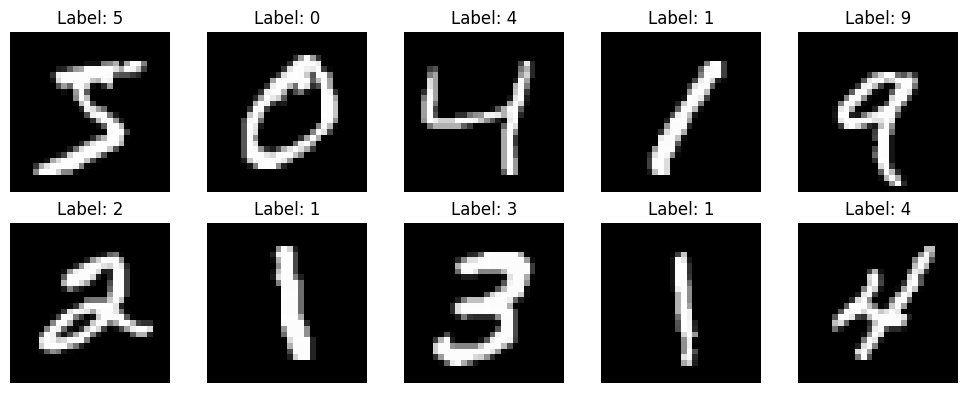

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

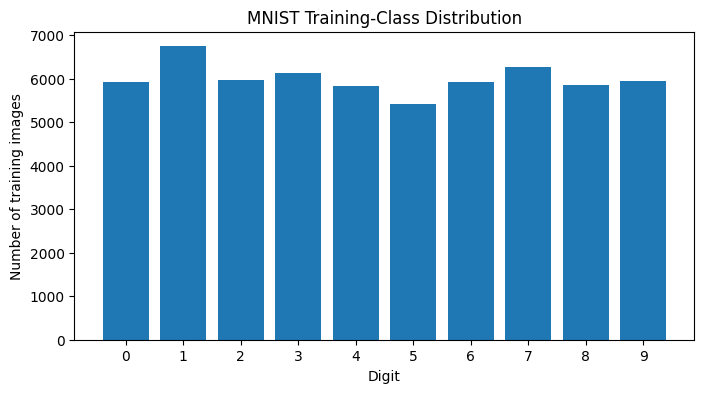

,Digit,Count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


In [4]:
classes, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(classes, counts)
plt.xticks(classes)
plt.xlabel('Digit')
plt.ylabel('Number of training images')
plt.title('MNIST Training-Class Distribution')
plt.show()

pd.DataFrame({'Digit': classes, 'Count': counts})

## 4. Preprocessing

Normalize pixels from 0–255 to 0–1. For the CNN, add a channel dimension so the input shape is `(28, 28, 1)`.

In [5]:
X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

X_train_cnn = np.expand_dims(X_train, axis=-1)
X_test_cnn = np.expand_dims(X_test, axis=-1)

print('MLP input:', X_train.shape)
print('CNN input:', X_train_cnn.shape)
print('Pixel range:', X_train.min(), 'to', X_train.max())

MLP input: (60000, 28, 28)
CNN input: (60000, 28, 28, 1)
Pixel range: 0.0 to 1.0


# 5. Model 1 — MLP Baseline

Architecture: `784 → 128 → 32 → 10`

In [6]:
mlp_model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
], name='MLP_Baseline')

mlp_model.summary()

Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_mlp = mlp_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
mlp_train_time = time.time() - start

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9181 - loss: 0.2872 - val_accuracy: 0.9577 - val_loss: 0.1516
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9638 - loss: 0.1234 - val_accuracy: 0.9653 - val_loss: 0.1161
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9748 - loss: 0.0839 - val_accuracy: 0.9669 - val_loss: 0.1096
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9818 - loss: 0.0605 - val_accuracy: 0.9682 - val_loss: 0.1115
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9869 - loss: 0.0457 - val_accuracy: 0.9674 - val_loss: 0.1172
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9899 - loss: 0.0348 - val_accuracy: 0.9654 - val_loss: 0.1381
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9906 - loss: 0.0305 - val_accuracy: 0.9705 - val_loss: 0.1226
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9930 - loss: 0.0224

In [8]:
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
mlp_prob = mlp_model.predict(X_test, verbose=0)
mlp_pred = np.argmax(mlp_prob, axis=1)

print(f'MLP Test Loss    : {mlp_test_loss:.4f}')
print(f'MLP Test Accuracy: {mlp_test_accuracy*100:.2f}%')
print(f'MLP Parameters   : {mlp_model.count_params():,}')
print(f'MLP Train Time   : {mlp_train_time:.2f} sec')

MLP Test Loss    : 0.1311
MLP Test Accuracy: 97.42%
MLP Parameters   : 104,938
MLP Train Time   : 121.19 sec


# 6. Model 2 — Basic CNN

Architecture: `Conv32 → Pool → Conv64 → Pool → Dense64 → Softmax10`

In [9]:
cnn_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
], name='Basic_CNN')

cnn_model.summary()

Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
cnn_train_time = time.time() - start

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.9511 - loss: 0.1598 - val_accuracy: 0.9843 - val_loss: 0.0539
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9869 - val_loss: 0.0498
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9895 - loss: 0.0350 - val_accuracy: 0.9889 - val_loss: 0.0407
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - accuracy: 0.9928 - loss: 0.0246 - val_accuracy: 0.9893 - val_loss: 0.0408
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.9945 - loss: 0.0181 - val_accuracy: 0.9885 - val_loss: 0.0467
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9954 - loss: 0.0141 - val_accuracy: 0.9890 - val_loss: 0.0462
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - accuracy: 0.9959 - loss: 0.0120 - val_accuracy: 0.9904 - val_loss: 0.0417
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9969 -

In [11]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
cnn_prob = cnn_model.predict(X_test_cnn, verbose=0)
cnn_pred = np.argmax(cnn_prob, axis=1)

print(f'CNN Test Loss    : {cnn_test_loss:.4f}')
print(f'CNN Test Accuracy: {cnn_test_accuracy*100:.2f}%')
print(f'CNN Parameters   : {cnn_model.count_params():,}')
print(f'CNN Train Time   : {cnn_train_time:.2f} sec')

CNN Test Loss    : 0.0424
CNN Test Accuracy: 98.98%
CNN Parameters   : 121,930
CNN Train Time   : 566.86 sec


# 7. Model 3 — Improved CNN

Adds extra convolution layers, Batch Normalization, Dropout, Early Stopping, and learning-rate reduction.

In [12]:
improved_cnn = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.30),
    Dense(10, activation='softmax')
], name='Improved_CNN')

improved_cnn.summary()

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,202 (1.79 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 192 (768.00 B)

In [15]:
improved_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5
)

start = time.time()
history_improved = improved_cnn.fit(
    X_train_cnn, y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
improved_train_time = time.time() - start

Epoch 1/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 241s 316ms/step - accuracy: 0.9641 - loss: 0.1251 - val_accuracy: 0.9876 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 2/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 228s 304ms/step - accuracy: 0.9756 - loss: 0.0851 - val_accuracy: 0.9839 - val_loss: 0.0598 - learning_rate: 0.0010


In [16]:
improved_test_loss, improved_test_accuracy = improved_cnn.evaluate(X_test_cnn, y_test, verbose=0)
improved_prob = improved_cnn.predict(X_test_cnn, verbose=0)
improved_pred = np.argmax(improved_prob, axis=1)

print(f'Improved CNN Test Loss    : {improved_test_loss:.4f}')
print(f'Improved CNN Test Accuracy: {improved_test_accuracy*100:.2f}%')
print(f'Improved CNN Parameters   : {improved_cnn.count_params():,}')
print(f'Improved CNN Train Time   : {improved_train_time:.2f} sec')

Improved CNN Test Loss    : 0.0370
Improved CNN Test Accuracy: 98.70%
Improved CNN Parameters   : 468,202
Improved CNN Train Time   : 469.59 sec


# 8. Training curves

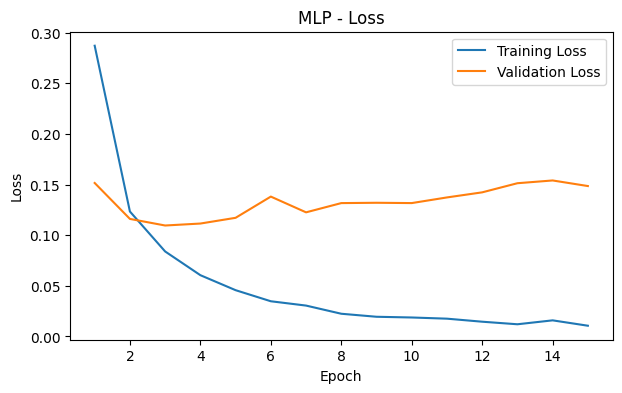

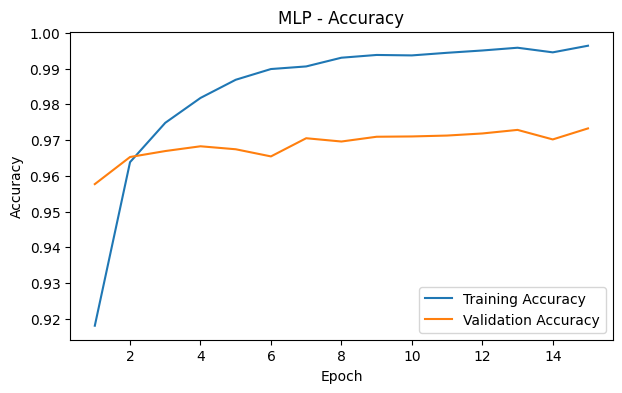

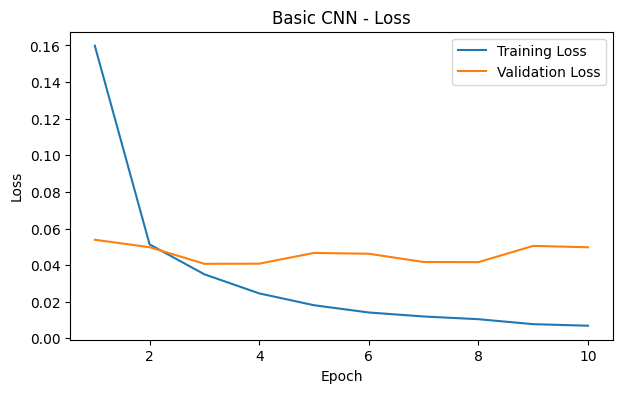

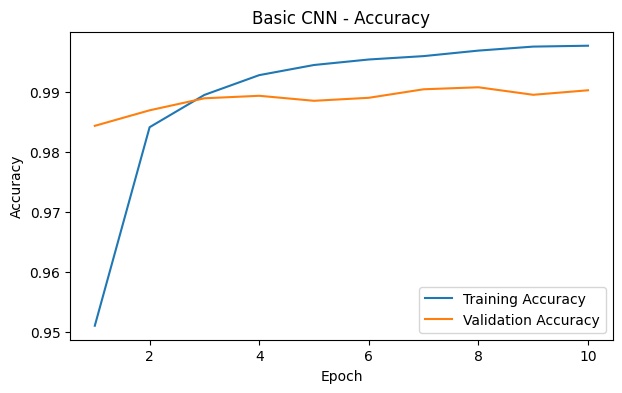

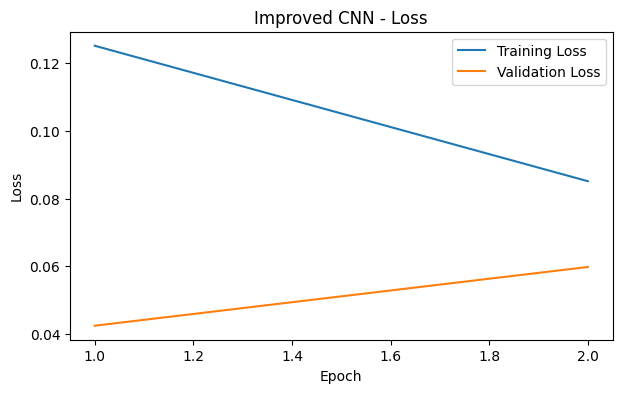

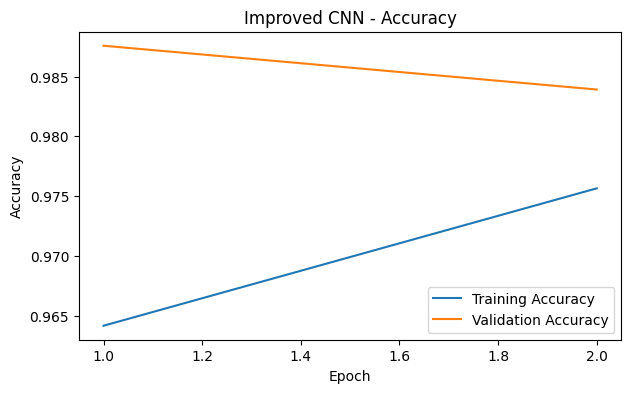

In [17]:
def plot_history(history, title):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.show()

plot_history(history_mlp, 'MLP')
plot_history(history_cnn, 'Basic CNN')
plot_history(history_improved, 'Improved CNN')

# 9. Model comparison

In [18]:
comparison = pd.DataFrame({
    'Model': ['MLP', 'Basic CNN', 'Improved CNN'],
    'Test Accuracy (%)': [
        mlp_test_accuracy * 100,
        cnn_test_accuracy * 100,
        improved_test_accuracy * 100
    ],
    'Test Loss': [mlp_test_loss, cnn_test_loss, improved_test_loss],
    'Parameters': [
        mlp_model.count_params(),
        cnn_model.count_params(),
        improved_cnn.count_params()
    ],
    'Training Time (sec)': [mlp_train_time, cnn_train_time, improved_train_time]
})
comparison

,Model,Test Accuracy (%),Test Loss,Parameters,Training Time (sec)
0,MLP,97.420001,0.131085,104938,121.189557
1,Basic CNN,98.979998,0.042429,121930,566.856781
2,Improved CNN,98.699999,0.036990,468202,469.593021


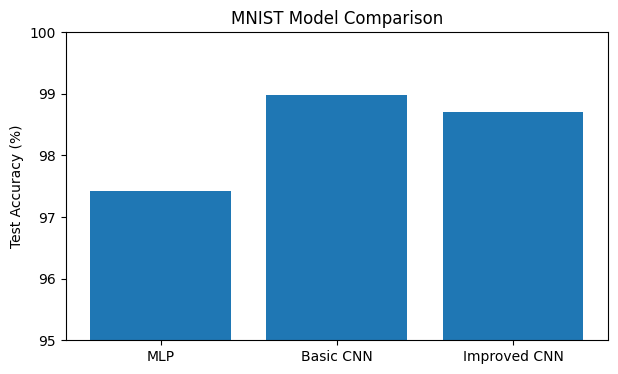

In [25]:
plt.figure(figsize=(7, 4))
plt.bar(comparison['Model'], comparison['Test Accuracy (%)'])
plt.ylabel('Test Accuracy (%)')
plt.title('MNIST Model Comparison')
plt.ylim(95, 100)
plt.show()

# 10. Select and analyze the best model

In [19]:
model_candidates = {
    'MLP': (mlp_model, mlp_test_accuracy, mlp_pred, mlp_prob, X_test),
    'Basic CNN': (cnn_model, cnn_test_accuracy, cnn_pred, cnn_prob, X_test_cnn),
    'Improved CNN': (improved_cnn, improved_test_accuracy, improved_pred, improved_prob, X_test_cnn)
}

best_name = max(model_candidates, key=lambda name: model_candidates[name][1])
best_model, best_accuracy, best_pred, best_prob, best_input = model_candidates[best_name]

print('Best model:', best_name)
print(f'Best test accuracy: {best_accuracy*100:.2f}%')

Best model: Basic CNN
Best test accuracy: 98.98%


## Confusion matrix

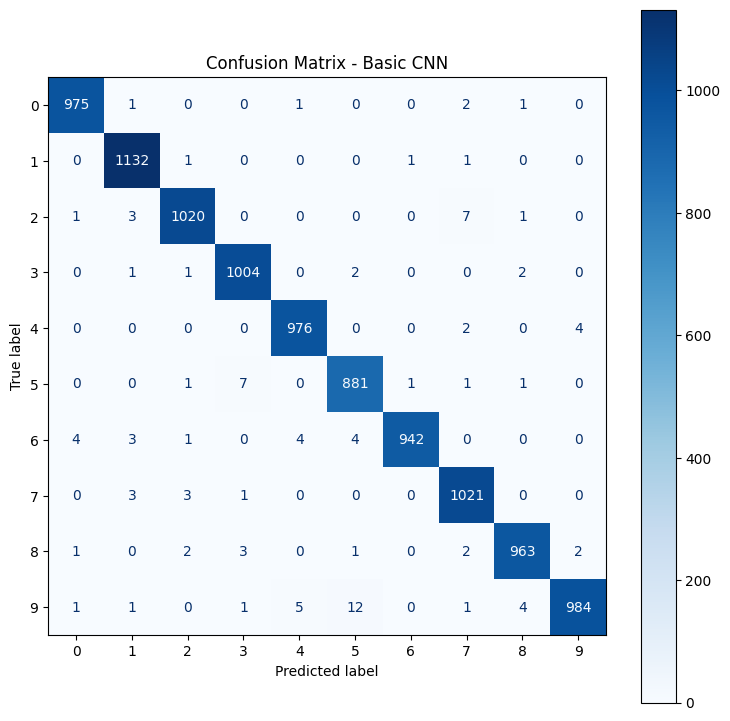

In [20]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

## Classification report

In [21]:
print(classification_report(y_test, best_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9929    0.9949    0.9939       980
           1     0.9895    0.9974    0.9934      1135
           2     0.9913    0.9884    0.9898      1032
           3     0.9882    0.9941    0.9911      1010
           4     0.9899    0.9939    0.9919       982
           5     0.9789    0.9877    0.9833       892
           6     0.9979    0.9833    0.9905       958
           7     0.9846    0.9932    0.9889      1028
           8     0.9907    0.9887    0.9897       974
           9     0.9939    0.9752    0.9845      1009

    accuracy                         0.9898     10000
   macro avg     0.9898    0.9897    0.9897     10000
weighted avg     0.9898    0.9898    0.9898     10000



# 11. Misclassified examples

Misclassified test images: 102


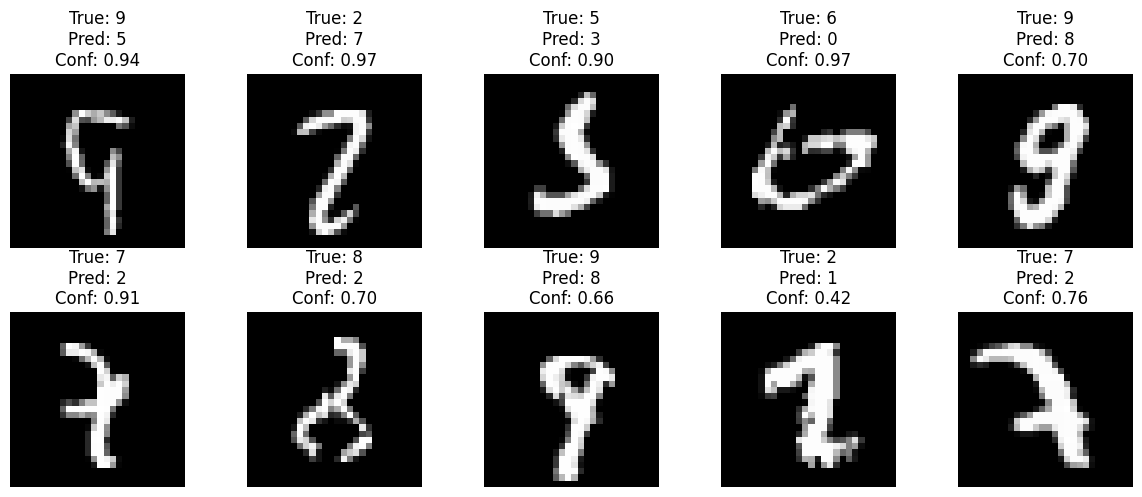

In [22]:
wrong_indices = np.where(best_pred != y_test)[0]
print('Misclassified test images:', len(wrong_indices))

plt.figure(figsize=(12, 5))
for i, idx in enumerate(wrong_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    confidence = best_prob[idx][best_pred[idx]]
    plt.title(f'True: {y_test[idx]}\nPred: {best_pred[idx]}\nConf: {confidence:.2f}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# 12. Single-image inference

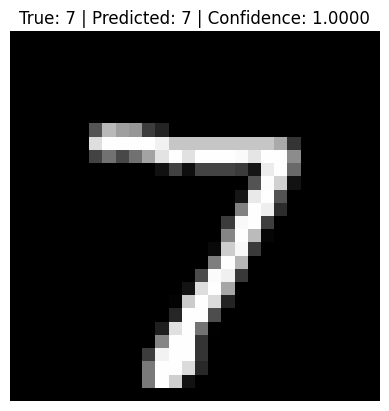

0: 0.000000
1: 0.000000
2: 0.000000
3: 0.000000
4: 0.000000
5: 0.000000
6: 0.000000
7: 1.000000
8: 0.000000
9: 0.000000


In [23]:
index = 0
image = best_input[index:index+1]
probabilities = best_model.predict(image, verbose=0)[0]
prediction = np.argmax(probabilities)

plt.imshow(X_test[index], cmap='gray')
plt.title(
    f'True: {y_test[index]} | Predicted: {prediction} | '
    f'Confidence: {probabilities[prediction]:.4f}'
)
plt.axis('off')
plt.show()

for digit, probability in enumerate(probabilities):
    print(f'{digit}: {probability:.6f}')

# 13. Optional model saving

In [24]:
# Uncomment after training if you want to save the models.
# mlp_model.save('mlp_mnist.keras')
# cnn_model.save('basic_cnn_mnist.keras')
# improved_cnn.save('improved_cnn_mnist.keras')

# 14. Key conclusions

- The MLP is a strong baseline but immediately flattens the image.
- CNNs preserve spatial relationships and learn local features such as strokes and edges.
- Backpropagation is handled automatically by TensorFlow during `model.fit()`.
- Adam uses gradients to update model parameters.
- Validation curves help detect overfitting.
- Confusion matrices and misclassified examples provide deeper error analysis than accuracy alone.

### Interview summary
> I implemented MNIST handwritten-digit classification and compared an MLP baseline with CNN architectures. I normalized the 28×28 grayscale images, trained the models using sparse categorical cross-entropy and Adam, and evaluated them on the 10,000-image test set. The CNN improved over the MLP because convolutional layers preserve spatial structure and learn local image features. I also performed training-curve analysis, confusion-matrix evaluation, per-class reporting, and misclassification analysis.